In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms,datasets
from torchvision.models import ResNet50_Weights
from PIL import Image
from torch.utils.data import DataLoader
import prettypyplot as pplt
import seaborn as sns
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import torch.nn.functional as F
import cv2
import pandas as pd

In [3]:
transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='../train_oversampling',transform=transform)
class_names=dataset_train.classes
dataset_test=datasets.ImageFolder(root='../test',transform=transform)
dataset_test_german=datasets.ImageFolder(root='../../../../data3/test_for_spanish_model',transform=transform)
print(dataset_test.classes)
dataset_val=datasets.ImageFolder(root='../val',transform=transform)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)
dataloader_test_german=DataLoader(dataset_test_german,batch_size=32,shuffle=True)
class_names=['BAS','EOS','EBO','IG','LYT','MON','NGS','PLA']

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [4]:
model = torch.load('resnet_model_free_lastlayer.pth',weights_only=False,map_location=torch.device('cpu'))
if isinstance(model, torch.nn.DataParallel):
    model = model.module


In [5]:
weights = ResNet50_Weights.DEFAULT
device = 'cpu'
preprocess = weights.transforms()
criterion=nn.CrossEntropyLoss()
# X_batch,y_batch=next(iter(dataloader_train))
# y_pred=model(preprocess(X_batch.to(device)))
# criterion(y_pred,y_batch.to(device))

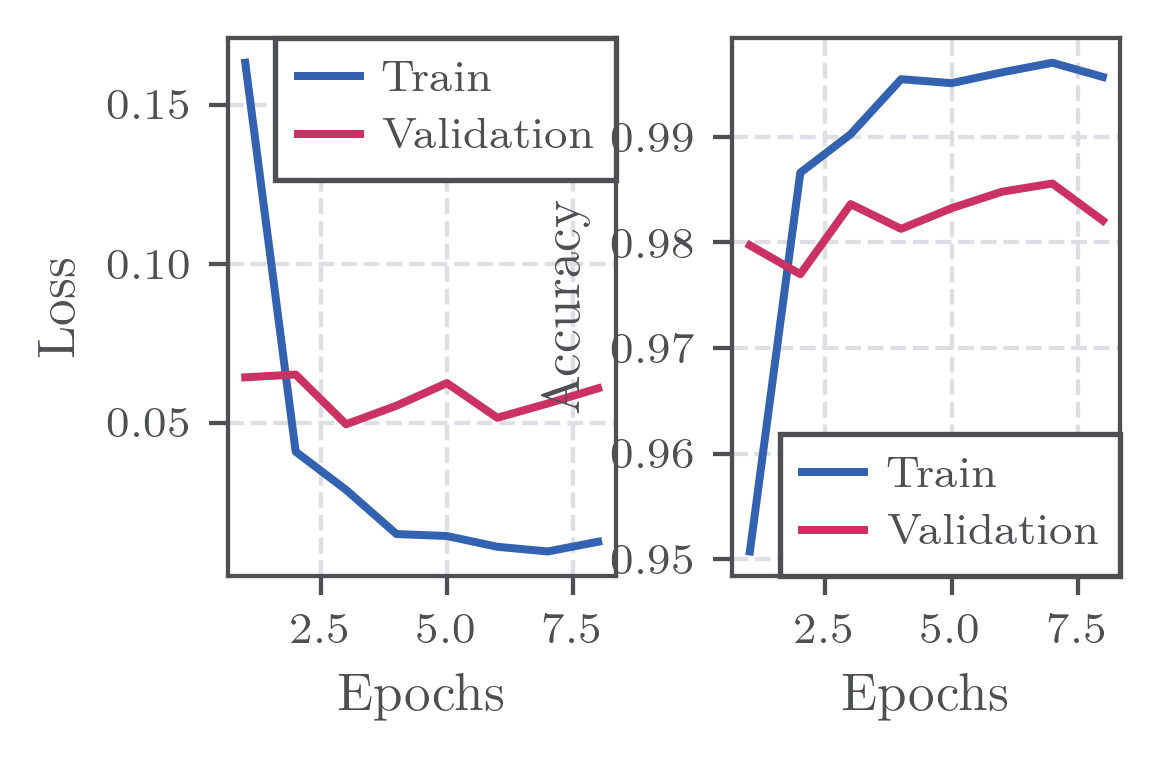

In [8]:
pplt.use_style()
data=np.loadtxt('./history_resnet50_free_lastlayer.txt')
train_loss,train_acc,validation_loss,validation_acc=data[:,0],data[:,1],data[:,2],data[:,3]
fig,ax=plt.subplots(1,2,figsize=(3,2),gridspec_kw={'wspace':0.3})
ax[0].plot(np.arange(len(train_loss))+1,train_loss,label='Train')
ax[0].plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend();
#plt.subplot(122)
ax[1].plot(np.arange(len(train_acc))+1,train_acc,label='Train')
ax[1].plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
pplt.savefig('loss_acc_resnet_free_lastlater.png',dpi=300);

In [9]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    loss_val_total = 0
    predictions, true_vals = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = preprocess(X_batch).to(device), y_batch.to(device)

            outputs = model(X_batch.to(torch.float32))

            if hasattr(outputs, "logits"):  # Inception case
                loss = criterion(outputs.logits, y_batch)
                y_pred = outputs.logits
            else:
                loss = criterion(outputs, y_batch)
                y_pred = outputs

            loss_val_total += loss.item()
            predictions.extend(y_pred.detach().cpu().numpy())
            true_vals.extend(y_batch.cpu().numpy())

    loss_val_avg = loss_val_total / len(dataloader)
    predictions = np.argmax(np.array(predictions), axis=-1)
    true_vals = np.array(true_vals)

    acc = accuracy_score(true_vals, predictions)
    return loss_val_avg, acc, true_vals, predictions


# --- Run on test set ---
test_loss, test_acc, y_true, y_pred = evaluate(dataloader_test, model, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Test Loss: 0.0838 | Test Accuracy: 98.13%

              precision    recall  f1-score   support

         BAS       0.99      0.97      0.98       183
         EOS       1.00      1.00      1.00       468
         EBO       0.99      0.97      0.98       233
          IG       0.97      0.96      0.96       435
         LYT       0.97      1.00      0.98       183
         MON       0.98      0.99      0.98       214
         NGS       0.96      0.98      0.97       500
         PLA       1.00      0.99      1.00       353

    accuracy                           0.98      2569
   macro avg       0.98      0.98      0.98      2569
weighted avg       0.98      0.98      0.98      2569



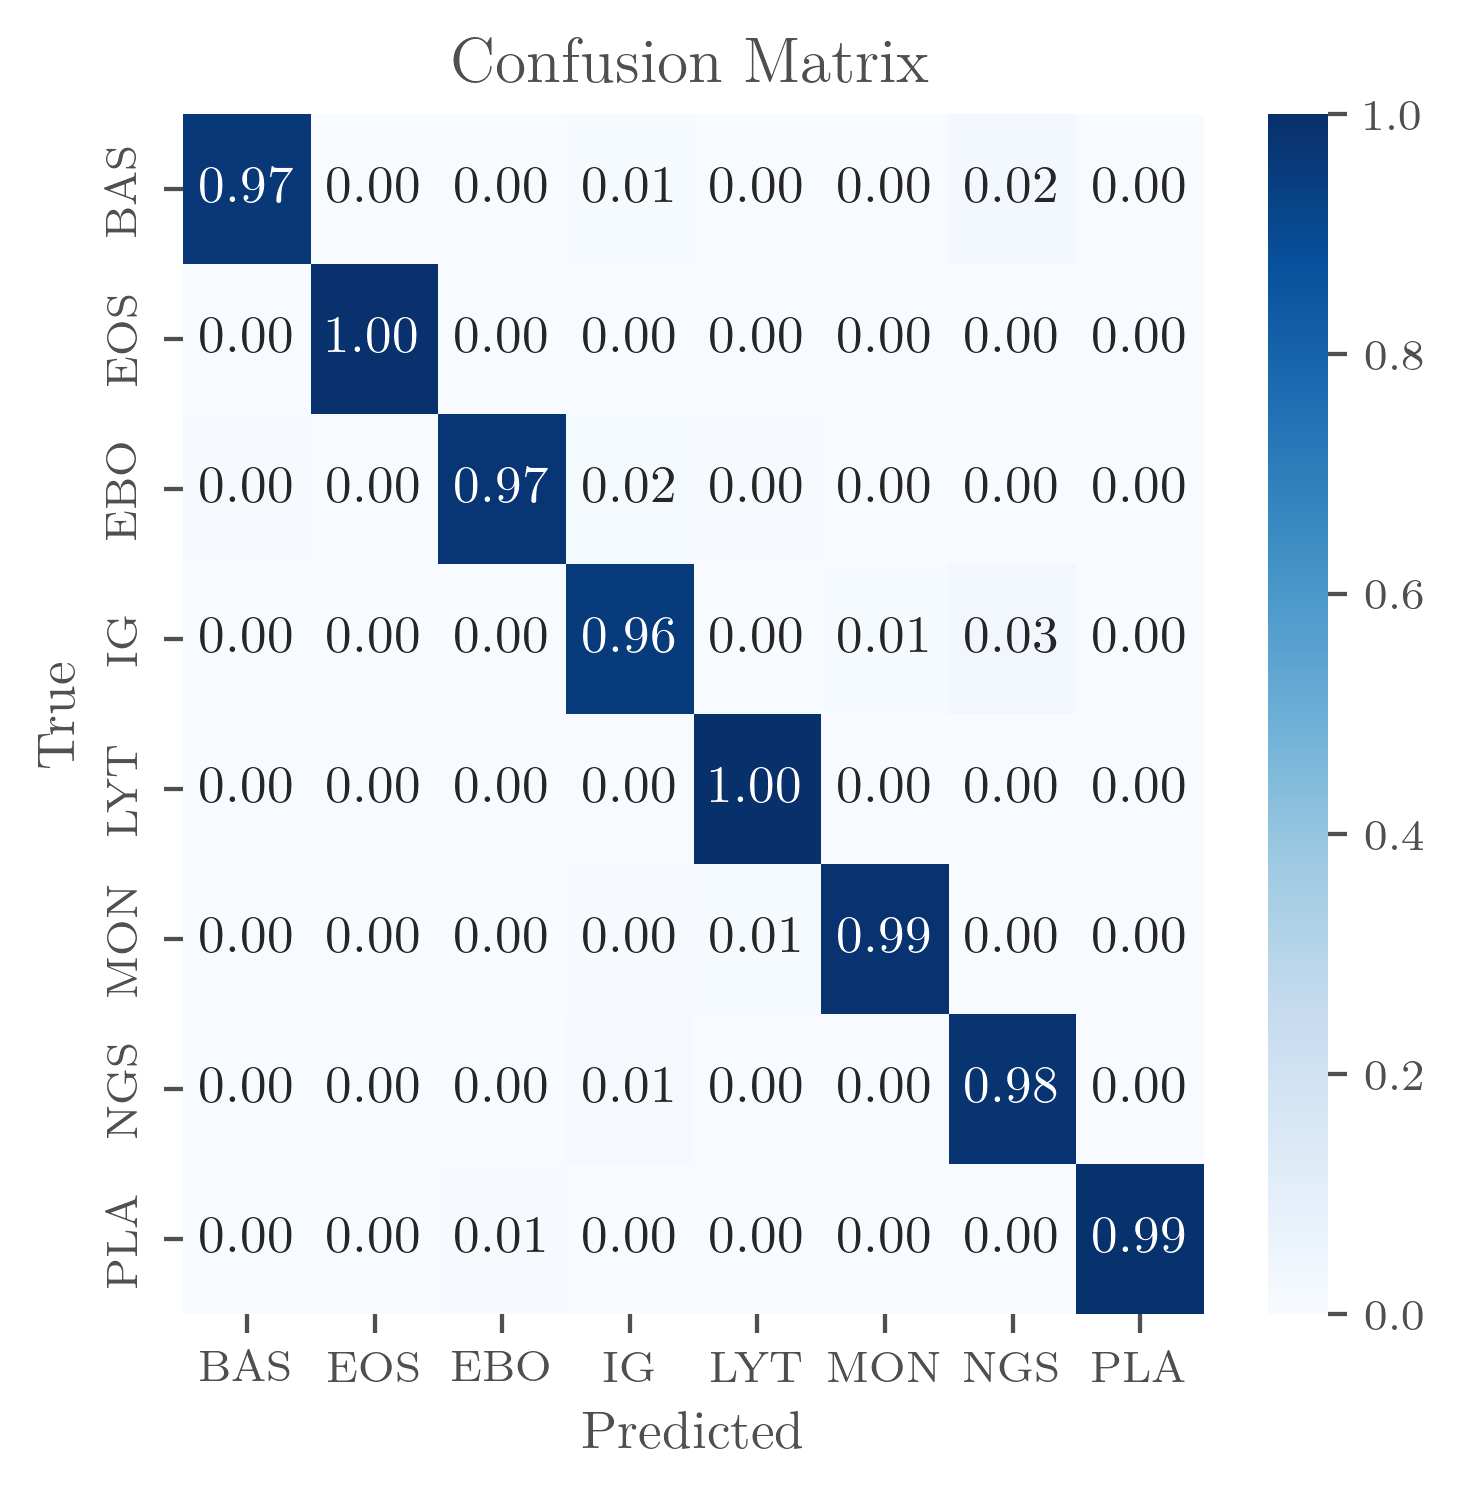

In [10]:
pplt.use_style()
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
#plt.xticks(rotation=45)
plt.title('Confusion Matrix')
pplt.savefig('cm_resnet_free_lastlayer.png',dpi=300)
plt.show()

In [13]:
def metrics_from_confusion(y_true, y_pred, class_names=None):
    cm = confusion_matrix(y_true, y_pred)  # shape (n_classes, n_classes)
    n_classes = cm.shape[0]

    sensitivity = []  # Recall
    specificity = []
    precision = []
    f1_scores = []

    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        sens = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        f1 = (2 * prec * sens) / (prec + sens) if (prec + sens) > 0 else 0

        sensitivity.append(sens)
        specificity.append(spec)
        precision.append(prec)
        f1_scores.append(f1)

    # Put results in a table
    df = pd.DataFrame({
        "Class": class_names if class_names else [f"Class {i}" for i in range(n_classes)],
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-score": f1_scores
    })
    return df
df_metrics = metrics_from_confusion(y_true, y_pred, class_names=class_names)
df_metrics2=df_metrics.set_index('Class')
df_round=df_metrics2.round(2)
display(df_round)
display(df_round.describe())

,Sensitivity (Recall),Specificity,Precision,F1-score
Class,,,,
BAS,0.97,1.00,0.99,0.98
EOS,1.00,1.00,1.00,1.00
EBO,0.97,1.00,0.99,0.98
IG,0.96,0.99,0.97,0.96
LYT,1.00,1.00,0.97,0.98
MON,0.99,1.00,0.98,0.98
NGS,0.98,0.99,0.96,0.97
PLA,0.99,1.00,1.00,1.00


,Sensitivity (Recall),Specificity,Precision,F1-score
count,8.00000,8.000000,8.00000,8.000000
mean,0.98250,0.997500,0.98250,0.981250
std,0.01488,0.004629,0.01488,0.013562
min,0.96000,0.990000,0.96000,0.960000
25%,0.97000,0.997500,0.97000,0.977500
50%,0.98500,1.000000,0.98500,0.980000
75%,0.99250,1.000000,0.99250,0.985000
max,1.00000,1.000000,1.00000,1.000000


In [12]:
def make_gradcam_heatmap(img_tensor, model, target_layer_name, pred_index=None):   
    # Skip forward to get target layer predictions and activations
    def forward_hook(module, input, output):
        model.features = output

    # Register a hook on the target layer to retrieve its outputs
    hook = model._modules.get(target_layer_name).register_forward_hook(forward_hook)
    
    # Perform a forward pass to obtain model outputs
    output = model(img_tensor)
    
    # Remove hook after getting activations
    hook.remove()

    # If no prediction index is provided, use the one with the highest probability
    if pred_index is None:
        pred_index = output.argmax(dim=1).item()
    
    # Class probability value
    y = output[0, pred_index]
    
    # Skip backwards to get the gradients of the target layer
    model.zero_grad() # Reset gradients
    model.features.retain_grad() # Keep target layer gradients
    y.backward(retain_graph=True) # Calculate gradients by backpropagation

    # Get target layer gradients and activations
    gradients = model.features.grad[0]
    activations = model.features[0]

    # Apply average global pooling on gradients
    pooled_grads = torch.mean(gradients, dim=[1, 2])

    # Weight activations by gradients
    for i in range(len(pooled_grads)):
        activations[i, :, :] *= pooled_grads[i]

    # Calculate the heatmap
    heatmap = torch.mean(activations, dim=0).detach().numpy()
    heatmap = np.maximum(heatmap, 0) # Keep only positive values
    heatmap /= np.max(heatmap) # Normalize the heatmap

    return heatmap, pred_index


In [15]:
pplt.use_style()
model.eval()  # make sure we're in eval mode

n = 8
batch_count = 0
count = 1
for X_batch, y_batch in dataloader_val:
    

    for i in range(len(X_batch)):
        # Original image for plotting
        img_disp = X_batch[i].permute(1, 2, 0).cpu().numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())  # normalize for display

        # Preprocess for model (if dataloader isn't already normalized)
        img_tensor = preprocess(X_batch[i]).unsqueeze(0)  # shape [1, C, H, W]

        # Grad-CAM
        heatmap, pred_label = make_gradcam_heatmap(img_tensor, model, "layer4")

        # Resize heatmap to match image size
        heatmap_resized = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
        heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]  # jet colormap

        # Overlay
        overlay = 0.4 * heatmap_color + 0.6 * img_disp
        overlay = np.clip(overlay, 0, 1)

        # Labels
        true_label = y_batch[i].item()

        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
        pred_class = torch.argmax(output, dim=1).item()

        # Plot
        fig = plt.figure(figsize=(5, 5))
        fig.add_subplot(1, 2, 1)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title("Grad-CAM overlaid")

        fig.add_subplot(1, 2, 2)
        plt.imshow(img_disp)
        plt.axis("off")
        plt.title(fr"T: {class_names[true_label]}/P: {class_names[pred_class]}")

        # Save
        save_dir = "val" if true_label == pred_label else "val/miss_classification"
        pplt.savefig(f"{save_dir}/{class_names[true_label]}_{class_names[pred_class]}_{count}.png", dpi=300)
        plt.close()
        count += 1
    batch_count += 1
    if batch_count >= n:
        break


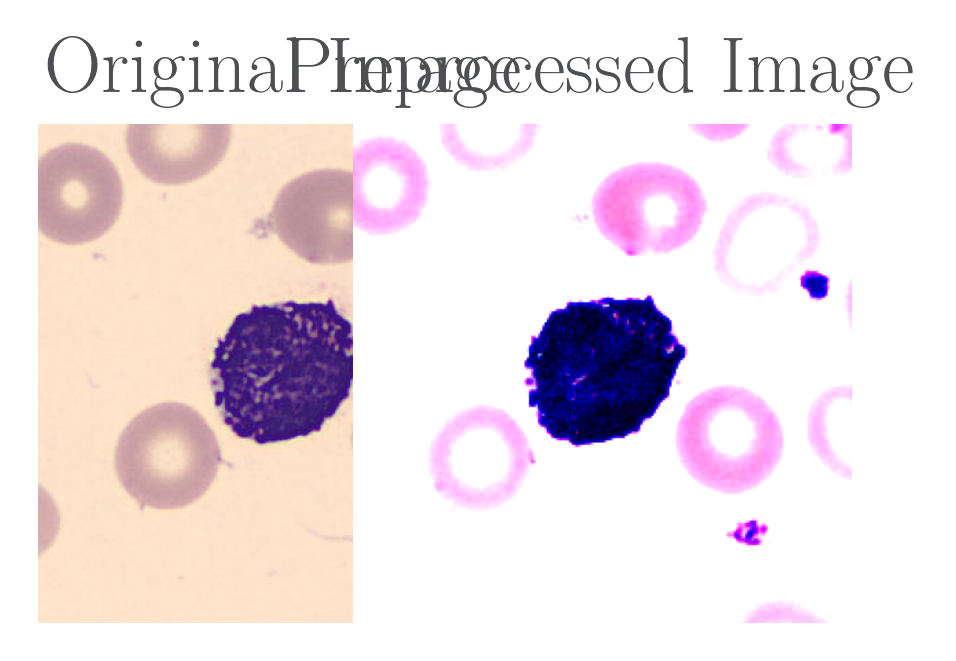

In [5]:
pplt.use_style()
img_path = "../test/basophil/BA_580.jpg"
img = Image.open(img_path)

# Preprocess using ResNet50 transforms
preprocess = weights.transforms()
img_tensor = preprocess(img)

# Convert preprocessed tensor to NumPy for visualization
img_np = img_tensor.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
img_np = img_np.clip(0, 1)  # Clip values to [0,1] if normalized

# Plot side by side
fig, axes = plt.subplots(1, 2, gridspec_kw={'wspace':-0.45})

# Original image
axes[0].imshow(img)
axes[0].set_title("Original Image",size='15')
axes[0].axis("off")

# Preprocessed image
axes[1].imshow(img_np)
axes[1].set_title("Preprocessed Image",size='15')
axes[1].axis("off")
pplt.savefig('processing.png')
plt.show()